### Task 1: Predictive Modeling Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV

In [3]:
#Using the 80-20 rule
train = pd.read_csv('churn-bigml-80.csv')
test = pd.read_csv('churn-bigml-20.csv')

In [4]:
print("Training set:", train.shape)
print("Testing set:", test.shape)

Training set: (2666, 20)
Testing set: (667, 20)


In [5]:
print(train.columns.tolist())
print("\nChurn distribution:")
print(train['Churn'].value_counts())

['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

Churn distribution:
Churn
False    2278
True      388
Name: count, dtype: int64


In [6]:
train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [8]:
#Encoding Categorical Variables 
le = LabelEncoder()

for col in ['State', 'International plan', 'Voice mail plan', 'Churn']:
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [14]:
#Numerical Feature Scaling
continuous_cols = ['Account length', 'Number vmail messages', 'Total day minutes', 
                   'Total day calls', 'Total day charge', 'Total eve minutes',
                   'Total eve calls', 'Total eve charge', 'Total night minutes',
                   'Total night calls', 'Total night charge', 'Total intl minutes',
                   'Total intl calls', 'Total intl charge', 'Customer service calls']

X_train = train.drop('Churn', axis=1)
y_train = train['Churn']
X_test = test.drop('Churn', axis=1)
y_test = test['Churn']

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [15]:
pd.DataFrame(X_train, columns=train.drop('Churn', axis=1).columns).head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,16,0.692163,415,0,1,1.247508,1.579670,0.484868,1.579942,-0.058619,-0.050781,-0.058445,0.857403,-0.469031,0.856707,-0.085020,-0.597527,-0.085681,-0.429172
1,35,0.161278,415,0,1,1.320985,-0.329918,1.135375,-0.330194,-0.095916,0.147654,-0.095397,1.048458,0.149054,1.049293,1.242179,-0.597527,1.242921,-0.429172
2,31,0.919686,415,0,0,-0.589414,1.179302,0.685024,1.179465,-1.554439,0.494917,-1.554963,-0.759668,0.200561,-0.758391,0.704125,0.216894,0.698194,-1.191955
3,35,-0.420168,408,1,0,-0.589414,2.212509,-1.466653,2.212675,-2.718509,-0.596479,-2.718922,-0.084083,-0.572045,-0.084339,-1.304609,1.031314,-1.307995,0.333610
4,36,-0.647691,415,1,0,-0.589414,-0.235822,0.634985,-0.235772,-1.022461,1.090224,-1.021482,-0.281046,1.076181,-0.281303,-0.049150,-0.597527,-0.045823,1.096392


In [16]:
#Decision Trees
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree:")
print(classification_report(y_test, y_pred_dt))

Decision Tree:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       572
           1       0.70      0.73      0.72        95

    accuracy                           0.92       667
   macro avg       0.83      0.84      0.83       667
weighted avg       0.92      0.92      0.92       667



In [17]:
#Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       572
           1       0.46      0.18      0.26        95

    accuracy                           0.85       667
   macro avg       0.67      0.57      0.59       667
weighted avg       0.82      0.85      0.82       667



In [18]:
#Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       572
           1       0.95      0.65      0.78        95

    accuracy                           0.95       667
   macro avg       0.95      0.82      0.87       667
weighted avg       0.95      0.95      0.94       667



In [19]:
## Summary Table
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-Score
0        Decision Tree  0.917541   0.704082  0.726316  0.715026
1  Logistic Regression  0.853073   0.459459  0.178947  0.257576
2        Random Forest  0.946027   0.953846  0.652632  0.775000


In [20]:
#Hyperparameter Tuning
param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 10],'min_samples_split': [2, 5, 10]}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.9527380174406759


In [21]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Tuned Random Forest:")
print(classification_report(y_test, y_pred_best))

Tuned Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       572
           1       0.93      0.66      0.77        95

    accuracy                           0.94       667
   macro avg       0.94      0.83      0.87       667
weighted avg       0.94      0.94      0.94       667



### Task 3: Natural Language Processing (NLP) - Sentiment Analysis

In [23]:
!pip install textblob wordcloud

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ------------------------------- ------ 524.3/625.0 kB 199.7 kB/s eta 0:00:01
   ------------------------------- ------ 524.3/625.0 kB 199.7 kB/s eta 0:00:01
   ---------------------------------------- 625.0/625.0 kB 223.3 kB/s  0:00:02

   -------------------- ------------------- 1/2 [textblob]
   -------------------- ------------------- 1/2 [t

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ekuap\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ekuap\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ekuap\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ekuap\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [43]:
df1 = pd.read_csv('3) Sentiment dataset.csv')
df1.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [44]:
df1.shape

(732, 15)

In [45]:
#Determining the unique values in the Sentiment column
df1['Sentiment'].unique().tolist()

[' Positive  ',
 ' Negative  ',
 ' Neutral   ',
 ' Anger        ',
 ' Fear         ',
 ' Sadness      ',
 ' Disgust      ',
 ' Happiness    ',
 ' Joy          ',
 ' Love         ',
 ' Amusement    ',
 ' Enjoyment    ',
 ' Admiration   ',
 ' Affection    ',
 ' Awe          ',
 ' Disappointed ',
 ' Surprise     ',
 ' Acceptance   ',
 ' Adoration    ',
 ' Anticipation ',
 ' Bitter       ',
 ' Calmness     ',
 ' Confusion    ',
 ' Excitement   ',
 ' Kind         ',
 ' Pride        ',
 ' Shame        ',
 ' Confusion ',
 ' Excitement ',
 ' Shame ',
 ' Elation       ',
 ' Euphoria      ',
 ' Contentment   ',
 ' Serenity      ',
 ' Gratitude     ',
 ' Hope          ',
 ' Empowerment   ',
 ' Compassion    ',
 ' Tenderness    ',
 ' Arousal       ',
 ' Enthusiasm    ',
 ' Fulfillment  ',
 ' Reverence     ',
 ' Compassion',
 ' Fulfillment   ',
 ' Reverence ',
 ' Elation   ',
 ' Despair         ',
 ' Grief           ',
 ' Loneliness      ',
 ' Jealousy        ',
 ' Resentment      ',
 ' Frustration

In [46]:
#Stripping all whitespaces
df1['Sentiment'] = df1['Sentiment'].str.strip()

In [48]:
# Checking what values look like after strip
df1['Sentiment'].unique()[:10]

array(['Positive', 'Negative', 'Neutral', 'Anger', 'Fear', 'Sadness',
       'Disgust', 'Happiness', 'Joy', 'Love'], dtype=object)

In [49]:
# Grouping the values into Positive, Negative and Neutral
positive = ['Positive', 'Joy', 'Happiness', 'Love', 'Amusement', 'Enjoyment',
            'Admiration', 'Affection', 'Awe', 'Excitement', 'Pride', 'Elation',
            'Euphoria', 'Contentment', 'Serenity', 'Gratitude', 'Hope',
            'Empowerment', 'Compassion', 'Tenderness', 'Enthusiasm', 'Fulfillment',
            'Reverence', 'Zest', 'Hopeful', 'Proud', 'Grateful', 'Empathetic',
            'Compassionate', 'Playful', 'Free-spirited', 'Inspired', 'Confident',
            'Overjoyed', 'Inspiration', 'Motivation', 'Satisfaction', 'Blessed',
            'Appreciation', 'Confidence', 'Accomplishment', 'Wonderment', 'Optimism',
            'Enchantment', 'PlayfulJoy', 'Mindfulness', 'DreamChaser', 'Elegance',
            'Harmony', 'Creativity', 'Radiance', 'Wonder', 'Rejuvenation', 'Coziness',
            'Adventure', 'FestiveJoy', 'InnerJourney', 'Freedom', 'Dazzle',
            'ArtisticBurst', 'CulinaryOdyssey', 'Resilience', 'Immersion', 'Spark',
            'Marvel', 'Positivity', 'Kindness', 'Friendship', 'Success', 'Thrill',
            'Exploration', 'Amazement', 'Romance', 'Captivation', 'Tranquility',
            'Grandeur', 'Energy', 'Celebration', 'Charm', 'Ecstasy', 'Colorful',
            'Hypnotic', 'Connection', 'Iconic', 'Journey', 'Engagement', 'Touched',
            'Triumph', 'Heartwarming', 'Solace', 'Breakthrough', 'Imagination',
            'Vibrancy', 'Mesmerizing', 'Happy', 'JoyfulReunion', 'Anticipation',
            'Acceptance', 'Determination', 'Calmness', 'Kind', 'Whimsy', 'Pensive',
            'Reflection', 'Contemplation', 'Curiosity', 'Nostalgia', 'Bittersweet',
            'Emotion', 'Winter Magic', 'Thrilling Journey', "Nature's Beauty",
            'Celestial Wonder', 'Creative Inspiration', 'Runway Creativity',
            "Ocean's Freedom", 'Whispers of the Past', 'Culinary Adventure',
            'Melodic', 'Adrenaline', 'Surprise', 'Relief', 'Mischievous',
            'Joy in Baking', 'Envisioning History', 'Renewed Effort', 'Sympathy',
            'Solitude', 'Heartache']

negative = ['Negative', 'Anger', 'Fear', 'Sadness', 'Disgust', 'Disappointed',
            'Shame', 'Despair', 'Grief', 'Loneliness', 'Jealousy', 'Resentment',
            'Frustration', 'Boredom', 'Anxiety', 'Intimidation', 'Helplessness',
            'Envy', 'Regret', 'Bitter', 'Bitterness', 'Yearning', 'Fearful',
            'Apprehensive', 'Overwhelmed', 'Jealous', 'Devastated', 'Frustrated',
            'Envious', 'Dismissive', 'Heartbreak', 'Betrayal', 'Suffering',
            'EmotionalStorm', 'Isolation', 'Disappointment', 'LostLove', 'Melancholy',
            'Exhaustion', 'Sorrow', 'Darkness', 'Desperation', 'Ruins', 'Desolation',
            'Loss', 'Hate', 'Bad', 'Sad', 'Embarrassed', 'Obstacle', 'Pressure',
            'Miscalculation', 'Challenge', 'Suspense']

def map_sentiment(sentiment):
    if sentiment in positive:
        return 'Positive'
    elif sentiment in negative:
        return 'Negative'
    else:
        return 'Neutral'

df1['Sentiment'] = df1['Sentiment'].apply(map_sentiment)

In [50]:
df1['Sentiment'].value_counts()

Sentiment
Positive    499
Negative    182
Neutral      51
Name: count, dtype: int64

In [51]:
#Tokenization, Lemmatization, Stopword Removal
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Tokenization and lowercasing
    tokens = word_tokenize(str(text).lower())
    # Removal of stopwords and non-alphabetic tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens 
              if word.isalpha() and word not in stop_words]
    return ' '.join(tokens)

df1['cleaned_text'] = df1['Text'].apply(preprocess_text)

In [53]:
df1[['Text', 'cleaned_text']].head()

,Text,cleaned_text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight


In [54]:
#Sentiment Analysis Using TextBlob
def get_sentiment(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df1['predicted_sentiment'] = df1['cleaned_text'].apply(get_sentiment)

In [56]:
df1['predicted_sentiment'].value_counts()

predicted_sentiment
Neutral     335
Positive    287
Negative    110
Name: count, dtype: int64

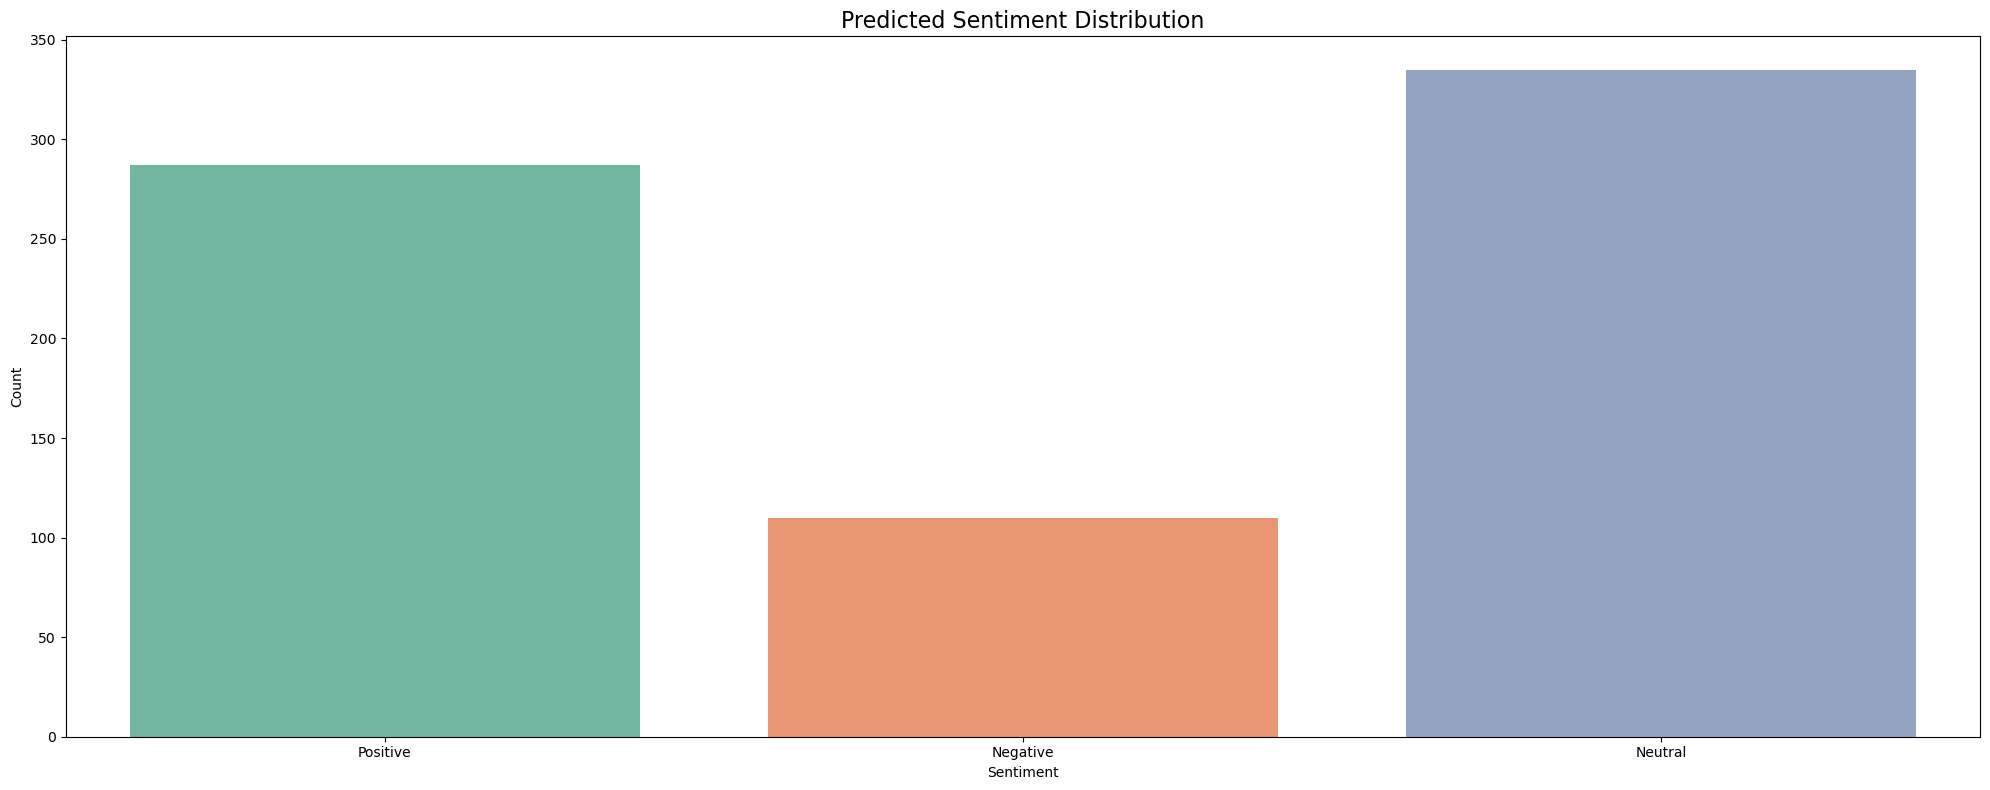

In [59]:
#Sentiment Analysis Visualizations
plt.figure(figsize=(20, 8))
sns.countplot(data=df1, x='predicted_sentiment', hue='predicted_sentiment', palette='Set2', legend=False)
plt.title('Predicted Sentiment Distribution', fontsize=16)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

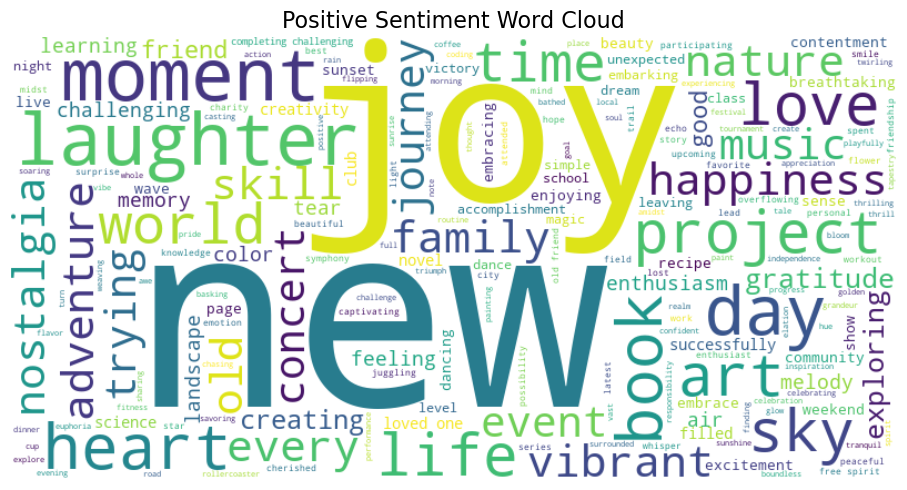

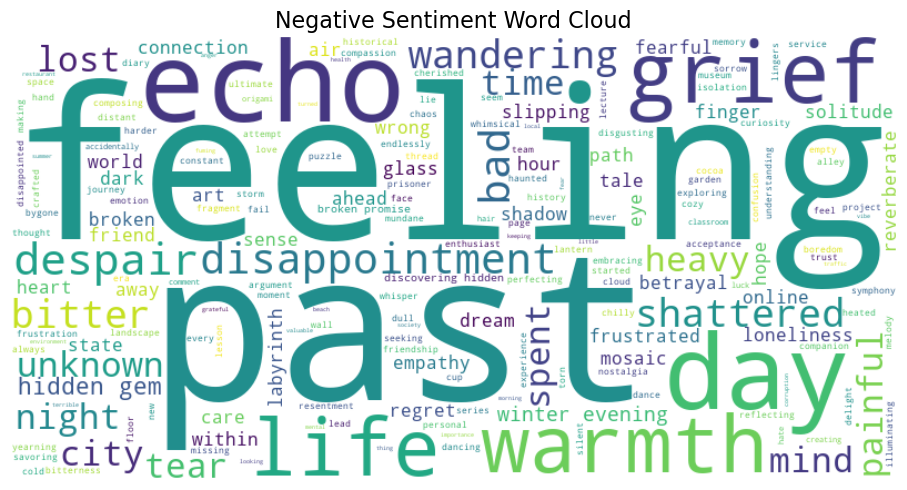

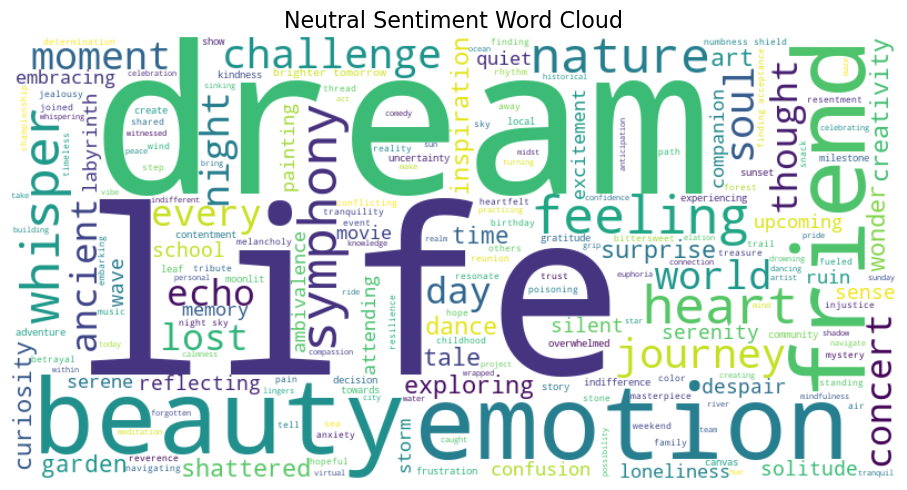

In [61]:
for sentiment in ['Positive', 'Negative', 'Neutral']:
    text = ' '.join(df1[df1['predicted_sentiment'] == sentiment]['cleaned_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'{sentiment} Sentiment Word Cloud', fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()